In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import hilbert

from synaptus import (
    MultilayerCartesianPulseEchoData,
    MultilayerOmegaKMigration,
    PhaseShiftMigration,
    load_mat_dataset,
    plot_us_image,
)

In [2]:
mat_dataset = load_mat_dataset("PlaneScan3D_PlexiAluFBH.mat")


In [3]:
psm = PhaseShiftMigration(
    raw_data=mat_dataset.raw_data,
    fs=mat_dataset.fs,
    f_low=mat_dataset.f_low,
    f_high=mat_dataset.f_high,
    x_step=mat_dataset.x_step,  # type:ignore
    y_step=mat_dataset.y_step,  # type:ignore
    t_delay=mat_dataset.t_delay,
    wave_velocities=mat_dataset.wave_vel,
    layer_thicknesses=mat_dataset.layer_thick,
)

In [4]:
images, z_vecs = psm.phase_shift_migrate()


In [5]:
images[0].shape, z_vecs[0].shape

((255, 111, 40), (255,))

In [6]:
z_vecs[1]

array([0.063   , 0.063455, 0.06391 , 0.064365, 0.06482 , 0.065275,
       0.06573 , 0.066185, 0.06664 , 0.067095, 0.06755 , 0.068005,
       0.06846 , 0.068915, 0.06937 , 0.069825, 0.07028 , 0.070735,
       0.07119 , 0.071645, 0.0721  , 0.072555, 0.07301 , 0.073465,
       0.07392 , 0.074375, 0.07483 , 0.075285, 0.07574 , 0.076195,
       0.07665 , 0.077105, 0.07756 , 0.078015, 0.07847 , 0.078925,
       0.07938 , 0.079835, 0.08029 , 0.080745, 0.0812  , 0.081655,
       0.08211 , 0.082565, 0.08302 , 0.083475, 0.08393 , 0.084385,
       0.08484 , 0.085295, 0.08575 , 0.086205, 0.08666 , 0.087115,
       0.08757 , 0.088025, 0.08848 , 0.088935, 0.08939 , 0.089845,
       0.0903  , 0.090755, 0.09121 , 0.091665, 0.09212 , 0.092575,
       0.09303 , 0.093485])

In [7]:
t_ind_1 = (psm.time_vec >= 88e-6) & (psm.time_vec <= 106e-6)  # Time gating, 1. layer
t_ind_2 = (psm.time_vec >= 110e-6) & (psm.time_vec <= 122.5e-6)  # Time gating, 2. layer

cscan_raw_plexi = abs(hilbert(psm.raw_data[t_ind_1, :, :], axis=0)).max(axis=0)
cscan_raw_alu = abs(hilbert(psm.raw_data[t_ind_2, :, :], axis=0)).max(axis=0)

z_ind_1 = (z_vecs[1] >= 0.068) & (z_vecs[1] <= 0.092)  # Depth gating, plexiglas layer
z_ind_2 = (z_vecs[2] >= 0.1) & (z_vecs[2] <= 0.14)  # Depth gating, aluminium layer

cscan_im_plexi = images[1][z_ind_1, :, :].max(axis=0)
cscan_im_alu = images[2][z_ind_2, :, :].max(axis=0)


# for image, z_vec in zip(images, z_vecs):
#     plot_us_image(image, y_val=z_vec)

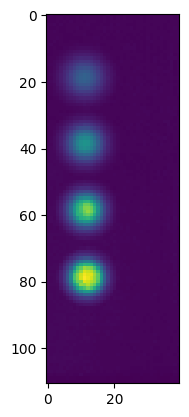

In [8]:
plt.imshow(cscan_raw_plexi)

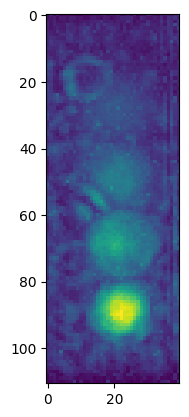

In [9]:
plt.imshow(cscan_raw_alu)

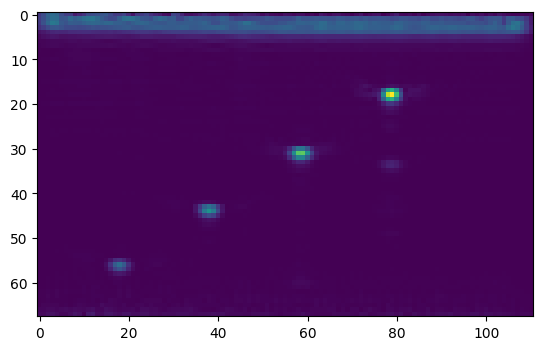

In [10]:
plt.imshow(np.squeeze(images[1][:, :, 12]))

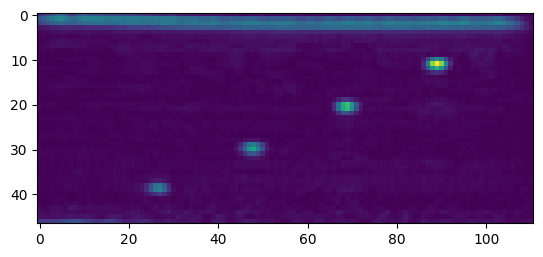

In [11]:
plt.imshow(np.squeeze(images[2][:, :, 23]))

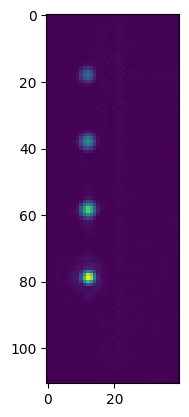

In [12]:
plt.imshow(cscan_im_plexi)

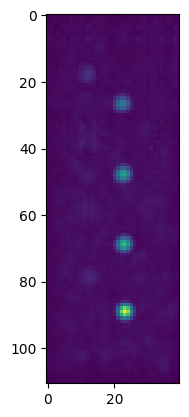

In [13]:
plt.imshow(cscan_im_alu)